# LISA: sensitivity, response, and the global fit

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**

> Google Colab worksheet for early-stage graduate students. Run from top to bottom; **Extension** sections may be skipped live.


## Goal and analysis map

This notebook follows the LISA Analysis Tools Workshop progression:

\[
\text{sensitivity}\rightarrow\text{TDI data}\rightarrow(a\mid b)
\rightarrow\mathrm{SNR}\rightarrow\mathcal L\rightarrow
\text{single source}\rightarrow\text{unknown overlapping catalogue}.
\]

We use `lisatools` for LISA sensitivity curves and JaxGB for an actual moving-constellation Galactic-binary response. The final exercise is a miniature version of the LATW global-fit challenge.

In [1]:
import os,sys,subprocess,importlib.util
IN_COLAB="COLAB_RELEASE_TAG" in os.environ
needed=("lisatools","gpubackendtools","jaxgb")
if any(importlib.util.find_spec(package) is None for package in needed):
    if IN_COLAB:
        subprocess.check_call([sys.executable,"-m","pip","install","-q","lisaanalysistools==1.2.5","gpubackendtools==0.1.1","jaxgb==0.2.1","astropy==7.2.0"])
    else: raise ImportError("Install the pinned LISA requirements, or run in Colab.")

In [2]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML,display
from matplotlib.animation import FuncAnimation
from jax import config
config.update("jax_enable_x64",True)
from lisatools.sensitivity import A1TDISens,E1TDISens,SensitivityMatrix,get_sensitivity
from lisatools.utils.constants import YRSID_SI
from lisaorbits import EqualArmlengthOrbits
from jaxgb.jaxgb import JaxGB
from jaxgb.params import GBObject
rng=np.random.default_rng(20260817); plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams["animation.html"]="jshtml"

## 1. LISA's band and source zoo

Ground-based detectors observe roughly tens of Hz to kHz. LISA targets approximately $10^{-4}$–$10^{-1}$ Hz, containing Galactic compact binaries, massive-black-hole binaries, EMRIs, stellar-origin binaries, stochastic backgrounds, and instrument noise. Long observations make many signals overlap.

Unlike a static right-angle detector, LISA is a heliocentric triangle that cartwheels as it orbits. Six delayed one-way laser links are combined into time-delay interferometry (TDI) variables. Orbital modulation helps localisation, while finite arms create a frequency-dependent response.

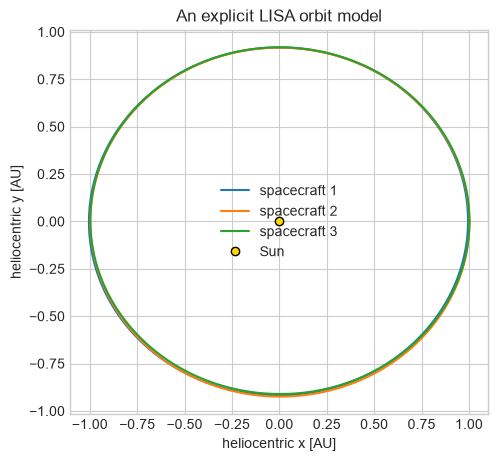

In [3]:
year=YRSID_SI; AU=149597870700.; orbits=EqualArmlengthOrbits(); times=np.linspace(0,year,240)
positions=np.asarray(orbits.compute_position(times,[1,2,3])); fig,ax=plt.subplots(figsize=(5.4,5.4))
for i,label in enumerate(["spacecraft 1","spacecraft 2","spacecraft 3"]): ax.plot(positions[:,i,0]/AU,positions[:,i,1]/AU,label=label)
ax.plot(0,0,"o",color="gold",mec="k",label="Sun"); ax.set(xlabel="heliocentric x [AU]",ylabel="heliocentric y [AU]",title="An explicit LISA orbit model",aspect="equal"); ax.legend(); plt.show()

## 2. Sensitivity and Galactic confusion

As in LATW Tutorial 1, start with the noise model. The unresolved Galactic foreground changes with observing time because longer data resolve and subtract more binaries.

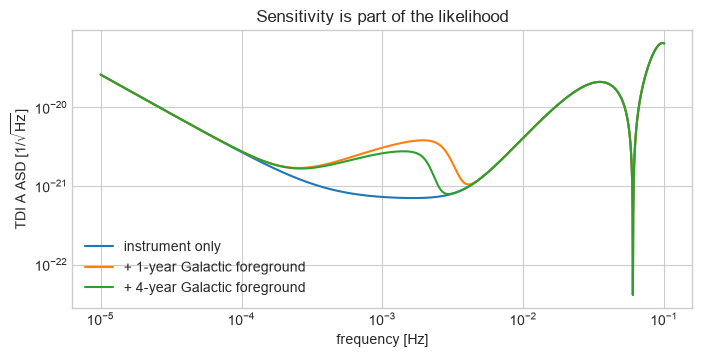

In [4]:
f_curve=np.logspace(-5,-1,1800)
instrument=SensitivityMatrix(f_curve,[A1TDISens,E1TDISens])
one_year=SensitivityMatrix(f_curve,[A1TDISens,E1TDISens],stochastic_params=(1*year,))
four_year=SensitivityMatrix(f_curve,[A1TDISens,E1TDISens],stochastic_params=(4*year,))
fig,ax=plt.subplots(figsize=(8,3.6))
ax.loglog(f_curve,np.sqrt(instrument.sens_mat[0]),label="instrument only")
ax.loglog(f_curve,np.sqrt(one_year.sens_mat[0]),label="+ 1-year Galactic foreground")
ax.loglog(f_curve,np.sqrt(four_year.sens_mat[0]),label="+ 4-year Galactic foreground")
ax.set(xlabel="frequency [Hz]",ylabel=r"TDI A ASD [1/$\sqrt{\mathrm{Hz}}$]",title="Sensitivity is part of the likelihood"); ax.legend(); plt.show()

## 3. Inner product, SNR, and likelihood

For independent A and E channels,
\[
(a\mid b)=4\Delta f\,\mathrm{Re}\sum_{X\in\{A,E\},k}\frac{a_{Xk}^*b_{Xk}}{S_X(f_k)},
\quad\rho_{\rm opt}=\sqrt{(h\mid h)},
\quad\log\mathcal L=-\tfrac12(d-h\mid d-h).
\]

These are the same objects as in LVK analysis. What changes is the instrument response, source durations, channels, band, and global model.

90-day optimal A+E SNR: 12.06


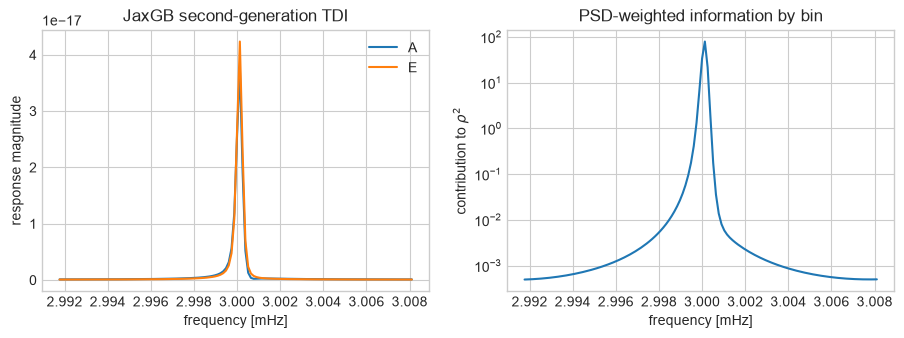

In [5]:
t_obs=90*86400.; simulator=JaxGB(orbits,t_obs=t_obs,t0=0,n=128)
source=GBObject(f0=np.array([3e-3]),fdot=np.array([1e-17]),A=np.array([2e-22]),ra=np.array([1.]),dec=np.array([.4]),psi=np.array([.3]),iota=np.array([.8]),phi0=np.array([.2]),t_init=0.)
parameters=source.to_jaxgb_array(t0=0); A,E,T=simulator.get_tdi(parameters,tdi_generation=2,tdi_combination="AET")
frequency=np.asarray(simulator.get_frequency_grid(simulator.get_kmin(parameters[:,0])))[0]; df=1/t_obs
template=np.stack([np.asarray(A)[0],np.asarray(E)[0]])
psd=np.stack([get_sensitivity(frequency,sens_fn=A1TDISens,stochastic_params=(t_obs,)),get_sensitivity(frequency,sens_fn=E1TDISens,stochastic_params=(t_obs,))])
def inner(a,b): return 4*df*np.real(np.sum(np.conj(a)*b/psd))
optimal_snr=np.sqrt(inner(template,template))
print(f"90-day optimal A+E SNR: {optimal_snr:.2f}")
fig,axes=plt.subplots(1,2,figsize=(11,3.4))
axes[0].plot(1e3*frequency,np.abs(template[0]),label="A"); axes[0].plot(1e3*frequency,np.abs(template[1]),label="E")
axes[0].set(xlabel="frequency [mHz]",ylabel="response magnitude",title="JaxGB second-generation TDI"); axes[0].legend()
axes[1].semilogy(1e3*frequency,4*df*np.sum(np.abs(template)**2/psd,axis=0))
axes[1].set(xlabel="frequency [mHz]",ylabel=r"contribution to $\rho^2$",title="PSD-weighted information by bin"); plt.show()

Perturb the source frequency and compare optimal SNR with detected/matched SNR. A loud template can still match the data poorly.

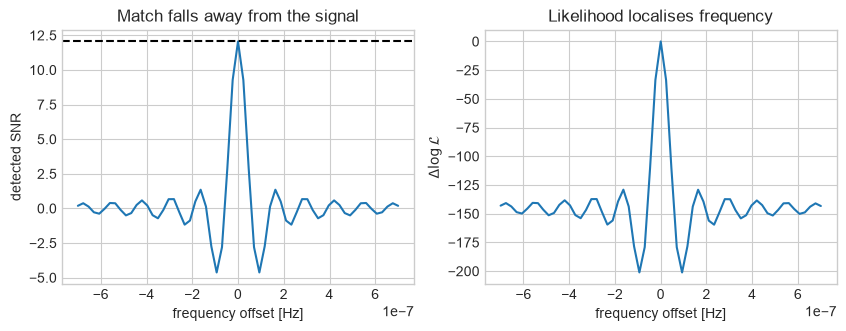

In [6]:
offsets=np.linspace(-7e-7,7e-7,61); detected=[]; logL=[]
for offset in offsets:
    trial=GBObject(f0=np.array([3e-3+offset]),fdot=np.array([1e-17]),A=np.array([2e-22]),ra=np.array([1.]),dec=np.array([.4]),psi=np.array([.3]),iota=np.array([.8]),phi0=np.array([.2]),t_init=0.)
    p=trial.to_jaxgb_array(t0=0); a,e,_=simulator.sum_tdi(p,int(simulator.get_kmin(parameters[:,0])[0]),int(simulator.get_kmin(parameters[:,0])[0])+simulator.n,tdi_generation=2,tdi_combination="AET")
    h=np.stack([np.asarray(a),np.asarray(e)]); rho=np.sqrt(inner(h,h)); detected.append(inner(template,h)/rho); logL.append(-.5*inner(template-h,template-h))
fig,axes=plt.subplots(1,2,figsize=(10,3.3)); axes[0].plot(offsets,detected); axes[0].axhline(optimal_snr,color="k",ls="--")
axes[0].set(xlabel="frequency offset [Hz]",ylabel="detected SNR",title="Match falls away from the signal")
axes[1].plot(offsets,np.array(logL)-np.max(logL)); axes[1].set(xlabel="frequency offset [Hz]",ylabel=r"$\Delta \log \mathcal{L}$",title="Likelihood localises frequency"); plt.show()

## 4. The global-fit problem

The LATW challenge combines a massive-black-hole binary with groups of Galactic binaries. The GLASS demonstration writes the same idea schematically as
\[
d=h_{\rm UCB}+h_{\rm VGB}+h_{\rm MBHB}+n(\eta).
\]
No source is analysed against pristine data: each block sees a residual containing the current estimates of all other source and noise blocks. Source count may itself be unknown, motivating reversible-jump/trans-dimensional methods.

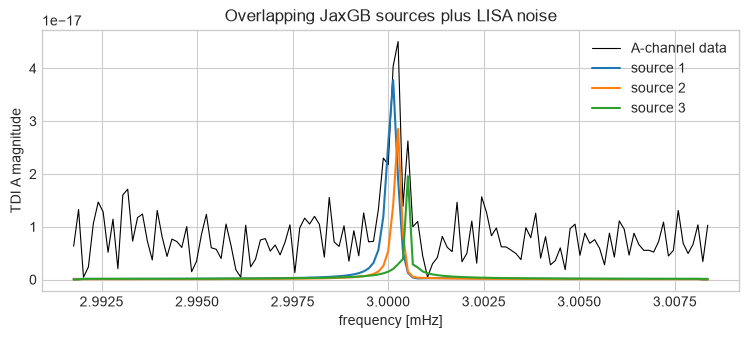

In [7]:
frequencies=np.array([3e-3,3.00012e-3,3.00025e-3]); true_scales=np.array([1.,.72,.48])
catalogue=GBObject(f0=frequencies,fdot=np.array([1e-17,.5e-17,1.5e-17]),A=np.full(3,2e-22),ra=np.array([1.,1.4,2.]),dec=np.array([.4,-.2,.7]),psi=np.array([.3,.8,1.1]),iota=np.array([.8,1.2,.5]),phi0=np.array([.2,1.5,2.4]),t_init=0.)
all_parameters=catalogue.to_jaxgb_array(t0=0); kmins=np.asarray(simulator.get_kmin(all_parameters[:,0])); kmin=int(kmins.min()); kmax=int(kmins.max()+simulator.n)
templates=[]
for row in np.asarray(all_parameters):
    a,e,_=simulator.sum_tdi(row[None,:],kmin,kmax,tdi_generation=2,tdi_combination="AET"); templates.append(np.stack([np.asarray(a),np.asarray(e)]))
templates=np.asarray(templates); common_frequency=np.arange(kmin,kmax)/t_obs
common_psd=np.stack([get_sensitivity(common_frequency,sens_fn=A1TDISens,stochastic_params=(t_obs,)),get_sensitivity(common_frequency,sens_fn=E1TDISens,stochastic_params=(t_obs,))])
noise=np.sqrt(common_psd/(4*df))*(rng.normal(size=common_psd.shape)+1j*rng.normal(size=common_psd.shape))
data=np.sum(true_scales[:,None,None]*templates,axis=0)+noise
def global_inner(a,b): return 4*df*np.real(np.sum(np.conj(a)*b/common_psd))
fig,ax=plt.subplots(figsize=(9,3.4)); ax.plot(1e3*common_frequency,np.abs(data[0]),color="k",lw=.8,label="A-channel data")
for i,h in enumerate(templates): ax.plot(1e3*common_frequency,np.abs(true_scales[i]*h[0]),label=f"source {i+1}")
ax.set(xlabel="frequency [mHz]",ylabel="TDI A magnitude",title="Overlapping JaxGB sources plus LISA noise"); ax.legend(); plt.show()

true       [1.   0.72 0.48]
one pass   [1.027 0.719 0.517]
joint      [1.071 0.721 0.521]
blocked    [1.071 0.721 0.521]


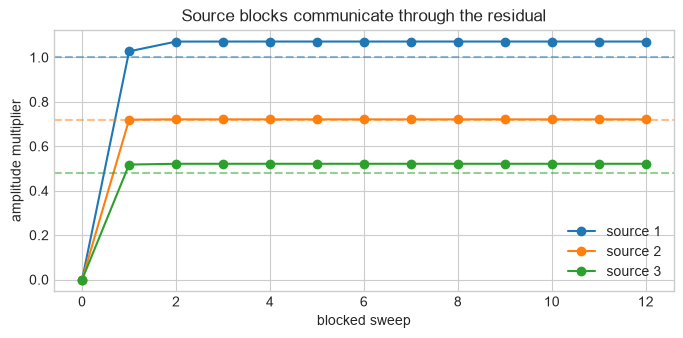

In [8]:
# One sequential pass, then a blocked conditional fit.
sequential=np.zeros(3); residual=data.copy()
for i,h in enumerate(templates): sequential[i]=global_inner(h,residual)/global_inner(h,h); residual-=sequential[i]*h
blocked=np.zeros(3); history=[blocked.copy()]
for sweep in range(12):
    for i,h in enumerate(templates):
        effective=data-np.sum(blocked[:,None,None]*templates,axis=0)+blocked[i]*h
        blocked[i]=global_inner(h,effective)/global_inner(h,h)
    history.append(blocked.copy())
history=np.asarray(history)

# The simultaneous weighted least-squares solution.
whitened_templates=(np.sqrt(4*df/common_psd)[None,:,:]*templates).reshape(3,-1).T
whitened_data=(np.sqrt(4*df/common_psd)*data).ravel()
design=np.vstack([whitened_templates.real,whitened_templates.imag]); target=np.r_[whitened_data.real,whitened_data.imag]
joint=np.linalg.lstsq(design,target,rcond=None)[0]
print("true      ",np.round(true_scales,3)); print("one pass  ",np.round(sequential,3)); print("joint     ",np.round(joint,3)); print("blocked   ",np.round(blocked,3))
fig,ax=plt.subplots(figsize=(8,3.4))
for i in range(3): ax.plot(history[:,i],"o-",label=f"source {i+1}"); ax.axhline(true_scales[i],color=f"C{i}",ls="--",alpha=.5)
ax.set(xlabel="blocked sweep",ylabel="amplitude multiplier",title="Source blocks communicate through the residual"); ax.legend(); plt.show()

## 5. A miniature unknown-source-count challenge

LATW Tutorial 6 uses RJMCMC so the number of Galactic binaries is inferred. Here we enumerate all eight subsets of three candidate templates and use BIC only as a fast classroom proxy—not as a replacement for evidence or RJMCMC.

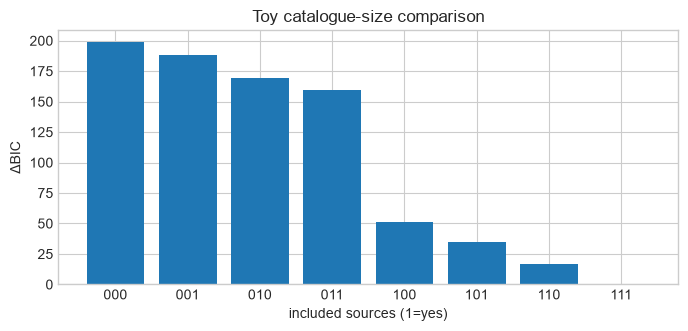

Preferred subset: 111 (the injected subset is 111)


In [9]:
model_scores=[]
for included_bits in itertools.product([0,1],repeat=3):
    included=np.flatnonzero(included_bits); model=np.zeros_like(data); n_parameters=len(included)
    if n_parameters:
        X=whitened_templates[:,included]; D=np.vstack([X.real,X.imag]); coefficients=np.linalg.lstsq(D,target,rcond=None)[0]
        model=np.sum(coefficients[:,None,None]*templates[included],axis=0)
    minus_two_logL=global_inner(data-model,data-model)
    bic=minus_two_logL+n_parameters*np.log(target.size); model_scores.append((included_bits,bic))
best=min(score for _,score in model_scores)
labels=["".join(map(str,bits)) for bits,_ in model_scores]; delta=[score-best for _,score in model_scores]
fig,ax=plt.subplots(figsize=(8,3.3)); ax.bar(labels,delta); ax.set(xlabel="included sources (1=yes)",ylabel=r"$\Delta$BIC",title="Toy catalogue-size comparison"); plt.show()
print("Preferred subset:",labels[int(np.argmin(delta))],"(the injected subset is 111)")

## Extension: animate the global residual

In [10]:
fig,ax=plt.subplots(figsize=(9,3.3)); line,=ax.plot([],[],lw=.8)
ax.set(xlim=(1e3*common_frequency.min(),1e3*common_frequency.max()),ylim=(0,1.1*np.max(np.abs(data[0]))),xlabel="frequency [mHz]",ylabel="A residual magnitude")
def animate_residual(i):
    residual=data-np.sum(history[i,:,None,None]*templates,axis=0); line.set_data(1e3*common_frequency,np.abs(residual[0])); ax.set_title(f"global residual after sweep {i}"); return (line,)
animation=FuncAnimation(fig,animate_residual,frames=len(history),interval=220); plt.close(fig); display(HTML(animation.to_jshtml()))

## Optional LISA Data Challenge input and boundary

The LDC portal requires authentication, so the live notebook uses deterministic synthetic data. An authenticated student can later upload a selected file in Colab.

```python
from google.colab import files
uploaded = files.upload()
```

This notebook uses a real sensitivity model, orbit, and TDI response, but the global exercise fits three amplitude coefficients from a fixed candidate catalogue. A research global fit must infer nonlinear parameters, source count, multiple source classes and TDI channels, instrument/foreground noise, and demonstrate convergence and coverage.

Continue with:

- local `lisa_analysis_workshop/tutorials/Tutorial1.ipynb` for sensitivity/SNR/likelihood;
- Tutorial 6 for fixed-dimensional and RJ Galactic-binary inference;
- `LATW-challenge-problem.ipynb` for an MBHB plus two trans-dimensional GB groups;
- [GLASS global analysis](https://arxiv.org/abs/2301.03673);
- [LISA Data Challenge files](https://lisa-ldc.in2p3.fr/file).